  ## در این مثال براساس داده های تولید محصولات هیدروکربنی در کشورهای مختلف برای سال های مختلف مورد استفاده قرار گرفته است. 
  دیتاست از آدرس زیر دانلود و پس از استخراج از حالت فشرده در پوشه کاری قرار داده شود.
  
  https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-5/world_primary_csv.zip

## فراخوانی کتابخانه ها

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### تعریف پارامترها

In [2]:
csv_file = "NewProcedure_Primary_CSV.csv"   # فایل استخراج شده از world_primary_csv.zip
country = "IR"        # مثال: "IR" ایران
product = "CRUDEOIL"  # یا "NGL" ، "OTHERCRUDE" ...
flow = "INDPROD"      # یا "PRODUCTION" یا "INDPROD" 
unit = "KBD"          # واحد: "KBD" یا "KBBL" یا غیره
horizon = 24
n_sim = 1000
seed = 42
desired_states = 3
laplace_alpha = 1.0
sample_paths_to_plot = 50

### فراخوانی داده ها

In [3]:
df = pd.read_csv(csv_file, dtype=str)
sel = df.query(
"REF_AREA == @country and ENERGY_PRODUCT == @product and FLOW_BREAKDOWN == @flow and UNIT_MEASURE == @unit"
).copy()
if sel.empty:
    raise ValueError(f"No rows found for {country}/{product}/{flow}/{unit} in {csv_file}")

countries = df['REF_AREA'].unique()
products = df['ENERGY_PRODUCT'].unique()
print("کشورهای موجود در دیتاست:",countries)
print("محصولات موجود در دیتاست:",products)

# convert
sel["OBS_VALUE"] = pd.to_numeric(sel["OBS_VALUE"], errors="coerce")
sel["TIME_PERIOD"] = pd.to_datetime(sel["TIME_PERIOD"], errors="coerce")
sel = sel.dropna(subset=["TIME_PERIOD", "OBS_VALUE"]) # drop malformed rows
if sel.empty:
    raise ValueError("No numeric date/value rows after cleaning.")


series = sel.sort_values("TIME_PERIOD").set_index("TIME_PERIOD")["OBS_VALUE"].astype(float)
# remove inf/nan
series = series.replace([np.inf, -np.inf], np.nan).dropna()
# remove non-positive because using log multiplicative updates
if (series <= 0).any():
    series = series[series > 0]


if len(series) < 6:
    raise ValueError("Too few valid observations in the series after cleaning.")


print(f"Loaded series for {country}/{product}/{flow}/{unit} with {len(series)} observations.")
print("Recent data:\n", series.tail(6))
print("Any NaN in series?", np.isnan(series).any())

کشورهای موجود در دیتاست: ['AE' 'AL' 'AM' 'AO' 'AR' 'AT' 'AU' 'AZ' 'BB' 'BD' 'BE' 'BG' 'BH' 'BM'
 'BN' 'BO' 'BR' 'BY' 'BZ' 'CA' 'CH' 'CL' 'CN' 'CO' 'CR' 'CU' 'CY' 'CZ'
 'DE' 'DK' 'DO' 'DZ' 'EC' 'EE' 'EG' 'ES' 'FI' 'FR' 'GA' 'GB' 'GD' 'GE'
 'GM' 'GQ' 'GR' 'GT' 'GY' 'HK' 'HN' 'HR' 'HT' 'HU' 'ID' 'IE' 'IN' 'IQ'
 'IR' 'IS' 'IT' 'JM' 'JP' 'KR' 'KW' 'KZ' 'LT' 'LU' 'LV' 'LY' 'MA' 'MD'
 'MK' 'MM' 'MT' 'MU' 'MX' 'MY' 'NE' 'NG' 'NI' 'NL' 'NO' 'NP' 'NZ' 'OM'
 'PA' 'PE' 'PG' 'PH' 'PL' 'PT' 'PY' 'QA' 'RO' 'RS' 'RU' 'SA' 'SD' 'SE'
 'SG' 'SI' 'SK' 'SR' 'SV' 'SY' 'SZ' 'TH' 'TJ' 'TN' 'TR' 'TT' 'TW' 'UA'
 'US' 'UY' 'VE' 'VN' 'YE' 'ZA']
محصولات موجود در دیتاست: ['CRUDEOIL' 'NGL' 'OTHERCRUDE' 'TOTCRUDE']
Loaded series for IR/CRUDEOIL/INDPROD/KBD with 193 observations.
Recent data:
 TIME_PERIOD
2018-02-01    3810.0
2018-03-01    3806.0
2018-04-01    3804.0
2018-05-01    3806.0
2018-06-01    3802.0
2018-07-01    3806.0
Name: OBS_VALUE, dtype: float64
Any NaN in series? False


### ساخت حالات و ماتریس گذار مارکوف

In [4]:
dy = series.pct_change().replace([np.inf, -np.inf], np.nan).dropna() * 100.0
# determine number of states from desired_states and actual variability
unique_vals = np.unique(np.round(dy, 8))
n_states = min(desired_states, unique_vals.size) if unique_vals.size >= 2 else 0
if n_states < 2:
    raise ValueError("Not enough variation to form at least two states. Try a different series or reduce desired_states.")


# split by quantiles
qs = np.linspace(0, 1, n_states + 1)
bins = np.quantile(dy, qs)
# ensure strictly increasing bins
for i in range(1, len(bins)):
    if bins[i] <= bins[i - 1]:
        bins[i] = bins[i - 1] + 1e-8


state_series = pd.cut(dy, bins=bins, labels=False, include_lowest=True).astype(int)
if state_series.empty:
    raise ValueError("State series is empty after binning.")


# count transitions
counts = np.zeros((n_states, n_states), dtype=float)
for a, b in zip(state_series[:-1], state_series[1:]):
    counts[a, b] += 1.0


# Laplace smoothing and transition probabilities
counts = counts + laplace_alpha
row_sums = counts.sum(axis=1, keepdims=True)
P = counts / row_sums


# parameters for each state (mean, sd of returns in percent)
mu_by_state = {}
sd_by_state = {}
overall_mu = dy.mean()
overall_sd = dy.std(ddof=1) if dy.std(ddof=1) > 0 else 1e-3


grouped = dy.groupby(state_series)
for st in range(n_states):
    if st in grouped.groups:
        vals = grouped.get_group(st).values
        mu_by_state[st] = np.nanmean(vals)
        sd_by_state[st] = np.nanstd(vals, ddof=1)
    if np.isnan(sd_by_state[st]) or sd_by_state[st] <= 0:
        sd_by_state[st] = overall_sd * 0.5 + 0.01
    else:
        mu_by_state[st] = overall_mu
        sd_by_state[st] = overall_sd


print("\nTransition matrix P:")
print(pd.DataFrame(P).round(3))
print("\nState mu, sd (percent changes):")
for st in sorted(mu_by_state):
    print(f" state {st}: mu={mu_by_state[st]:.4f}%, sd={sd_by_state[st]:.4f}%")

print("Row sums:", pd.DataFrame(P).sum(axis=1))



Transition matrix P:
       0      1      2
0  0.388  0.254  0.358
1  0.288  0.545  0.167
2  0.313  0.209  0.478

State mu, sd (percent changes):
 state 0: mu=0.0903%, sd=1.8882%
 state 1: mu=0.0903%, sd=1.8882%
 state 2: mu=0.0903%, sd=1.8882%
Row sums: 0    1.0
1    1.0
2    1.0
dtype: float64


### شبیه سازی مارکوف + مونت کارلو

In [5]:
np.random.seed(seed)
last_level = series.iloc[-1]
# choose last_state from last available state (note dy has one fewer obs than series)
last_state = int(state_series.iloc[-1])

n_states = P.shape[0]
sims = np.full((n_sim, horizon), np.nan)
for sim in range(n_sim):
    level = last_level
    state = last_state
    for t in range(horizon):
        probs = P[state]
        if np.any(np.isnan(probs)) or probs.sum() <= 0:
            probs = np.ones(n_states) / n_states
        next_state = np.random.choice(np.arange(n_states), p=probs)
        mu = mu_by_state.get(next_state, 0.0)
        sd = sd_by_state.get(next_state, 0.1)
        d = np.random.normal(mu, sd) # percent change
        level = level * np.exp(d / 100.0)
        sims[sim, t] = level
        state = next_state


print("Simulations shape:", sims.shape)
print("Any NaN?", np.isnan(sims).any())

for i in range(5):
    print(sims[i, :10])


# compute percentiles
p05 = np.percentile(sims, 5, axis=0)
p10 = np.percentile(sims, 10, axis=0)
p25 = np.percentile(sims, 25, axis=0)
p50 = np.percentile(sims, 50, axis=0)
p75 = np.percentile(sims, 75, axis=0)
p90 = np.percentile(sims, 90, axis=0)
p95 = np.percentile(sims, 95, axis=0)


print("p50 sample:", p50[:5])
print("p05 sample:", p05[:5])
print("p95 sample:", p95[:5])


Simulations shape: (1000, 24)
Any NaN? False
[3730.295253   3756.21668881 3779.47252383 3855.76126634 3817.14797254
 3782.89848158 3604.06823396 3672.64312631 3646.37118073 3598.86149449]
[3737.54273664 3630.73707787 3542.77672995 3487.50526021 3529.23696645
 3592.13809832 3581.34763392 3542.63172165 3446.28211991 3521.76754899]
[3845.68021723 3934.26018953 4041.15227766 4058.23438102 4042.26659557
 4017.91671377 3824.89650873 3853.41141341 3890.02099346 3881.34705569]
[3774.11156487 3843.94663461 3973.42039622 4043.15705618 4096.71443362
 4006.8208378  4057.70972881 4049.05357985 4025.50497237 4071.67491806]
[3747.53820158 3761.26988413 3827.65056972 3813.81664764 4019.53211926
 4030.29391815 3961.24672587 4038.66168211 4032.84785103 4093.31567848]
p50 sample: [3810.23763347 3809.11788491 3810.29652569 3812.79234788 3814.82575608]
p05 sample: [3694.3724329  3638.98712722 3600.22158289 3579.58273169 3555.02753706]
p95 sample: [3937.5441872  3978.03369551 4014.85478269 4058.54338056 410

### رسم نتایج

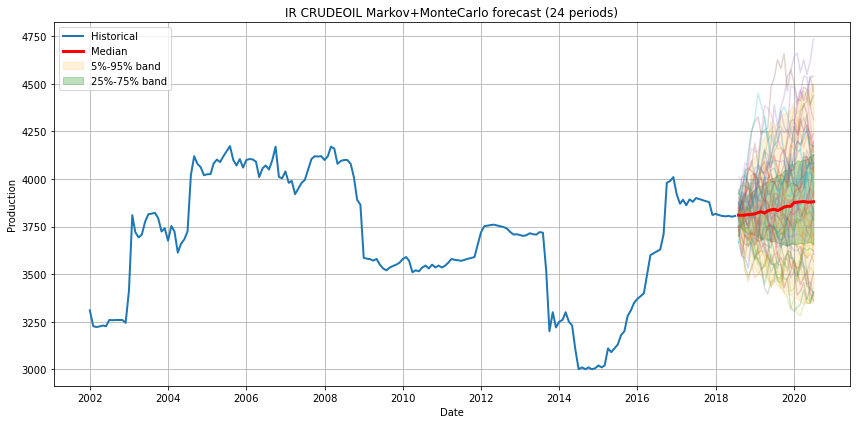

In [6]:
sample_paths = min(sample_paths_to_plot, sims.shape[0])
last_date = series.index[-1]
dates_future = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")


plt.figure(figsize=(12, 6))
plt.plot(series.index.to_numpy(), series.values, label="Historical", linewidth=2)


# رسم مسیرهای نمونه شبیه سازی شده
for i in range(sample_paths):
    plt.plot(dates_future.to_numpy(), sims[i, :], alpha=0.25)

# میانه و باندها
plt.plot(dates_future.to_numpy(), p50, label="Median", color="red", linewidth=3)
plt.fill_between(dates_future.to_numpy(), p05, p95, alpha=0.15, label="5%-95% band", color="orange")
plt.fill_between(dates_future.to_numpy(), p25, p75, alpha=0.25, label="25%-75% band", color="green")

plt.legend()
plt.grid(True)
plt.title(f"{country} {product} Markov+MonteCarlo forecast ({horizon} periods)")
plt.xlabel("Date")
plt.ylabel("Production")
plt.tight_layout()
plt.show()